# Gemini Benchmarking for Web Testing Agent

This notebook evaluates the performance of the Gemini model on the formatted Mind2Web dataset. We use a **Structured Response Schema** to ensure Gemini outputs valid execution actions.

In [ ]:
import os
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import google.generativeai as genai
from dotenv import load_dotenv

# Load environment variables from ai-qa-bot/.env
load_dotenv("../ai-qa-bot/.env")

GOOGLE_API_KEY = os.getenv("GOOGLE_GENERATIVE_AI_API_KEY")
genai.configure(api_key=GOOGLE_API_KEY)

# Define the Execution Response Schema
execution_response_schema = {
    "type": "object",
    "properties": {
        "currentStateDescription": {"type": "string"},
        "intendedActionDescription": {"type": "string"},
        "action": {
            "type": "object",
            "properties": {
                "kind": {
                    "type": "string", 
                    "enum": ["click", "type", "select_option", "navigate", "screenshot", "wait", "stop", "none", "press", "hover", "scrollIntoView", "drag", "select", "fill", "close", "switch_tab", "list_tabs", "close_tab", "new_tab"]
                },
                "ref": {"type": "string"},
                "text": {"type": "string"},
                "value": {"type": "string"},
                "selector": {"type": "string"},
                "url": {"type": "string"}
            },
            "required": ["kind"]
        },
        "isTaskComplete": {"type": "boolean"}
    },
    "required": ["currentStateDescription", "intendedActionDescription", "action", "isTaskComplete"]
}

model = genai.GenerativeModel('gemini-1.5-flash')

DATASET_PATH = "mind2web_execution_training.jsonl"
NUM_SAMPLES = 50 # Adjust as needed

In [ ]:
!pip install -q google-generativeai tqdm pandas matplotlib seaborn python-dotenv

## 1. Load Data

In [10]:
samples = []
if not os.path.exists(DATASET_PATH):
    print(f"Error: {DATASET_PATH} not found. Please run the formatter first.")
else:
    with open(DATASET_PATH, 'r') as f:
        for i, line in enumerate(f):
            if i >= NUM_SAMPLES: break
            samples.append(json.loads(line))
    print(f"Loaded {len(samples)} samples.")

Loaded 30 samples.


## 2. Run Evaluation with Schema Enforcement

In [11]:
results = []

for i, sample in enumerate(tqdm(samples, desc="Evaluating")):
    messages = sample['messages'][:-1]
    
    system_instruction = ""
    contents = []
    for m in messages:
        if m['role'] == 'system':
            system_instruction = m['content']
        elif m['role'] == 'user':
            contents.append({"role": "user", "parts": [m['content']]})
        elif m['role'] == 'assistant':
            contents.append({"role": "model", "parts": [m['content']]})

    try:
        response = model.generate_content(
            contents,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=execution_response_schema
            ),
            system_instruction=system_instruction
        )
        
        prediction = json.loads(response.text)
        ground_truth = sample['output']
        
        pred_action = prediction.get('action', {})
        gt_action = ground_truth.get('action', {})
        
        kind_match = pred_action.get('kind') == gt_action.get('kind')
        ref_match = pred_action.get('ref') == gt_action.get('ref')
        
        text_match = True
        if gt_action.get('kind') == 'type':
            text_match = str(pred_action.get('text', '')) == str(gt_action.get('text', ''))
        elif gt_action.get('kind') == 'select_option':
            text_match = str(pred_action.get('value', '')) == str(gt_action.get('value', ''))

        success = kind_match and ref_match and text_match
        
        results.append({
            "index": i,
            "success": success,
            "kind_match": kind_match,
            "ref_match": ref_match,
            "text_match": text_match,
            "predicted": pred_action,
            "actual": gt_action
        })
        
    except Exception as e:
        print(f"Error at sample {i}: {e}")
        results.append({
            "index": i, 
            "success": False, 
            "kind_match": False, 
            "ref_match": False, 
            "text_match": False, 
            "error": str(e)
        })
    
    time.sleep(1)

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Error at sample 0: GenerativeModel.generate_content() got an unexpected keyword argument 'system_instruction'


Evaluating:   3%|▎         | 1/30 [00:01<00:29,  1.00s/it]

Error at sample 1: GenerativeModel.generate_content() got an unexpected keyword argument 'system_instruction'


Evaluating:   7%|▋         | 2/30 [00:02<00:28,  1.00s/it]

...

Evaluating:  93%|█████████▎| 28/30 [00:28<00:02,  1.00s/it]

Error at sample 28: GenerativeModel.generate_content() got an unexpected keyword argument 'system_instruction'


Evaluating:  97%|█████████▋| 29/30 [00:29<00:01,  1.00s/it]

Error at sample 29: GenerativeModel.generate_content() got an unexpected keyword argument 'system_instruction'


Evaluating: 100%|██████████| 30/30 [00:30<00:00,  1.00s/it]


## 3. Results Visualization

KeyError: 'cannot use a single bool to index into setitem'

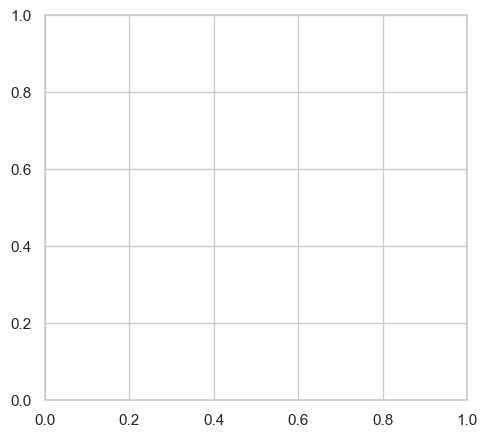

In [ ]:
if not results:
    print("No results to visualize.")
else:
    df = pd.DataFrame(results)
    plt.figure(figsize=(12, 5))
    sns.set_theme(style="whitegrid")

    plt.subplot(1, 2, 1)
    success_counts = df['success'].value_counts(normalize=True) * 100
    # Ensure both index values exist for consistent plotting
    for val in [False, True]:
        if val not in success_counts.index:
            success_counts[val] = 0.0
    success_counts = success_counts.sort_index()
    
    sns.barplot(x=success_counts.index, y=success_counts.values, palette="viridis")
    plt.title("Overall Success Rate (%)")
    plt.xticks([0, 1], ["Failure", "Success"])
    plt.ylabel("Percentage (%)")

    plt.subplot(1, 2, 2)
    metrics = {
        "Kind": df['kind_match'].mean(), 
        "Ref": df['ref_match'].mean(), 
        "Overall": df['success'].mean()
    }
    sns.barplot(x=list(metrics.keys()), y=[v*100 for v in metrics.values()], palette="magma")
    plt.title("Component Match Rates (%)")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()